# Train YOLO26n Human Detector With Classroom Postures

This notebook trains the regular one-class human detector on the merged dataset:

`training_yolo26_boxes_with_classroom_postures/data.yaml`

The dataset keeps class `0 = Human`. The new classroom posture exports are used only as additional human-box examples for detection. Posture class names are for the separate classification dataset, not this detector.


## Previous Local Training Attempts

The retained second-dataset checkpoint is not present in this checkout, so this notebook trains from the plain YOLO baseline checkpoint `yolo26n.pt`.

Available local runs:

### `yolo26n_human_boxes_baseline`

This was an attempted heavier CPU run:

- model: `yolo26n.pt`
- dataset: old `training_yolo26_boxes`
- `epochs=120`, `patience=30`
- `imgsz=640`
- `batch=-1`
- `mosaic=0.8`, `close_mosaic=10`
- `scale=0.5`, `translate=0.1`
- `hsv_v=0.25`, `hsv_h=0`, `hsv_s=0`
- `cos_lr=True`, `workers=0`, `device=cpu`

It only has 2 epochs in `results.csv`, so it was not a completed useful model. It was also too expensive for CPU and too slow for the intended inference budget.

### `yolo26n_human_boxes_cpu_small`

This was the successful local improvement attempt:

- model: `yolo26n.pt`
- dataset: old `training_yolo26_boxes`
- `epochs=80`, `patience=20`
- `imgsz=224`
- `batch=8`
- `mosaic=0.6`, `close_mosaic=5`
- `scale=0.35`, `translate=0.08`
- `hsv_v=0.25`, `hsv_h=0`, `hsv_s=0`
- `cos_lr=True`, `workers=0`, `device=cpu`

Local validation curve: best mAP50 `0.878` around epoch 72 and best mAP50-95 `0.531` around epoch 74. This shows the CPU-friendly setup worked better than the unfinished 640 run.

Because the stronger retained checkpoint is missing, the new run should start from `yolo26n.pt` but keep the proven CPU-friendly choices: nano model, `imgsz=224`, fixed `batch=8`, moderate augmentation, and longer patience.


## Recommended Hyperparameters For New Training

Default config is tuned for training from `yolo26n.pt` with up to about 4 hours on CPU:

- `model=yolo26n.pt`: required because the retained custom checkpoint is missing locally.
- `imgsz=224`: best speed choice; source images are `162x122` and `200x200`.
- `epochs=180`, `patience=45`: more room than the 80-epoch old run because this starts from baseline and has more data.
- `batch=8`, `workers=0`: stable Windows/Jupyter CPU settings.
- `mosaic=0.55`, `close_mosaic=20`: keep mosaic useful early, then train final epochs on natural frames.
- `hsv_h=0.0`, `hsv_s=0.0`, `hsv_v=0.30`: brightness only for grayscale/low-color imagery.
- `scale=0.35`, `translate=0.08`, `degrees=2.0`: moderate geometry for camera variation without unrealistic distortion.
- `fliplr=0.5`: valid for human detection boxes.

Avoid `imgsz=640` on CPU: it was already tried locally and did not finish meaningfully. If this run under-detects small people, the next experiment should be `imgsz=256`, not `320` or `640`.


In [1]:
from pathlib import Path
from collections import Counter
import csv
import random
import time

import cv2
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATASET = PROJECT_ROOT / "training_yolo26_boxes_with_classroom_postures"
DATA_YAML = DATASET / "data.yaml"
RUNS_DIR = PROJECT_ROOT / "runs" / "yolo26"
LOCAL_PRETRAINED_WEIGHTS = PROJECT_ROOT / "notebooks" / "yolo26n.pt"

if LOCAL_PRETRAINED_WEIGHTS.exists():
    PRETRAINED_WEIGHTS = LOCAL_PRETRAINED_WEIGHTS
    START_WEIGHTS_NOTE = "plain YOLO26n baseline checkpoint from local notebook folder"
else:
    PRETRAINED_WEIGHTS = "yolo26n.pt"
    START_WEIGHTS_NOTE = "plain YOLO26n baseline checkpoint; Ultralytics will use cache/download if needed"

TRAIN_NAME = "yolo26n_human_boxes_classroom_postures_from_baseline_cpu_img224"
SPLITS = ["train", "val", "test"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SEED = 42

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET)
print("Data YAML:", DATA_YAML)
print("Start weights:", PRETRAINED_WEIGHTS)
print("Start weights note:", START_WEIGHTS_NOTE)
print("Output:", RUNS_DIR / TRAIN_NAME)

if not DATA_YAML.exists():
    raise FileNotFoundError(f"Missing dataset YAML: {DATA_YAML}")


Project root: C:\Users\Hecos\Documents\sem\industry\vslam\code\object_detection
Dataset: C:\Users\Hecos\Documents\sem\industry\vslam\code\object_detection\training_yolo26_boxes_with_classroom_postures
Data YAML: C:\Users\Hecos\Documents\sem\industry\vslam\code\object_detection\training_yolo26_boxes_with_classroom_postures\data.yaml
Start weights: C:\Users\Hecos\Documents\sem\industry\vslam\code\object_detection\notebooks\yolo26n.pt
Start weights note: plain YOLO26n baseline checkpoint from local notebook folder
Output: C:\Users\Hecos\Documents\sem\industry\vslam\code\object_detection\runs\yolo26\yolo26n_human_boxes_classroom_postures_from_baseline_cpu_img224


## Dataset Sanity Check

This checks image counts, label pairing, background frames, object size distribution, and image sizes before training.


In [2]:
def read_yolo_label(path: Path):
    if not path.exists():
        return []
    rows = []
    text = path.read_text(encoding="utf-8").strip()
    if not text:
        return rows
    for line_no, line in enumerate(text.splitlines(), 1):
        parts = line.split()
        if len(parts) != 5:
            raise ValueError(f"Bad YOLO row in {path}:{line_no}: {line!r}")
        class_id = int(parts[0])
        values = tuple(float(v) for v in parts[1:])
        if class_id != 0 or any(v < 0 or v > 1 for v in values):
            raise ValueError(f"Invalid YOLO values in {path}:{line_no}: {line!r}")
        rows.append((class_id, *values))
    return rows

summary = []
image_sizes = Counter()
box_areas = []
empty_labels = []

for split in SPLITS:
    image_dir = DATASET / "images" / split
    label_dir = DATASET / "labels" / split
    images = [p for p in sorted(image_dir.iterdir()) if p.suffix.lower() in IMAGE_EXTS]
    labels = sorted(label_dir.glob("*.txt"))
    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}
    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems
    if missing_labels or missing_images:
        raise RuntimeError(f"{split}: missing_labels={len(missing_labels)}, missing_images={len(missing_images)}")

    boxes = 0
    for image_path in images:
        image = cv2.imread(str(image_path))
        if image is None:
            raise ValueError(f"Could not read image: {image_path}")
        h, w = image.shape[:2]
        image_sizes[(w, h)] += 1
        rows = read_yolo_label(label_dir / f"{image_path.stem}.txt")
        if not rows:
            empty_labels.append(label_dir / f"{image_path.stem}.txt")
        for _, _, _, bw, bh in rows:
            boxes += 1
            box_areas.append(bw * bh)
    summary.append({"split": split, "images": len(images), "labels": len(labels), "boxes": boxes})

print("Split summary:")
for row in summary:
    print(row)

print("Image sizes:")
for size, count in image_sizes.most_common():
    print(f"  {size[0]}x{size[1]}: {count}")

if box_areas:
    sorted_areas = sorted(box_areas)
    print("Box area ratio min/median/max:", sorted_areas[0], sorted_areas[len(sorted_areas)//2], sorted_areas[-1])
print("Background/empty label files:", len(empty_labels))


Split summary:
{'split': 'train', 'images': 708, 'labels': 708, 'boxes': 1031}
{'split': 'val', 'images': 202, 'labels': 202, 'boxes': 304}
{'split': 'test', 'images': 103, 'labels': 103, 'boxes': 146}
Image sizes:
  162x122: 557
  200x200: 456
Box area ratio min/median/max: 0.0015179115411860001 0.06651 1.0
Background/empty label files: 15


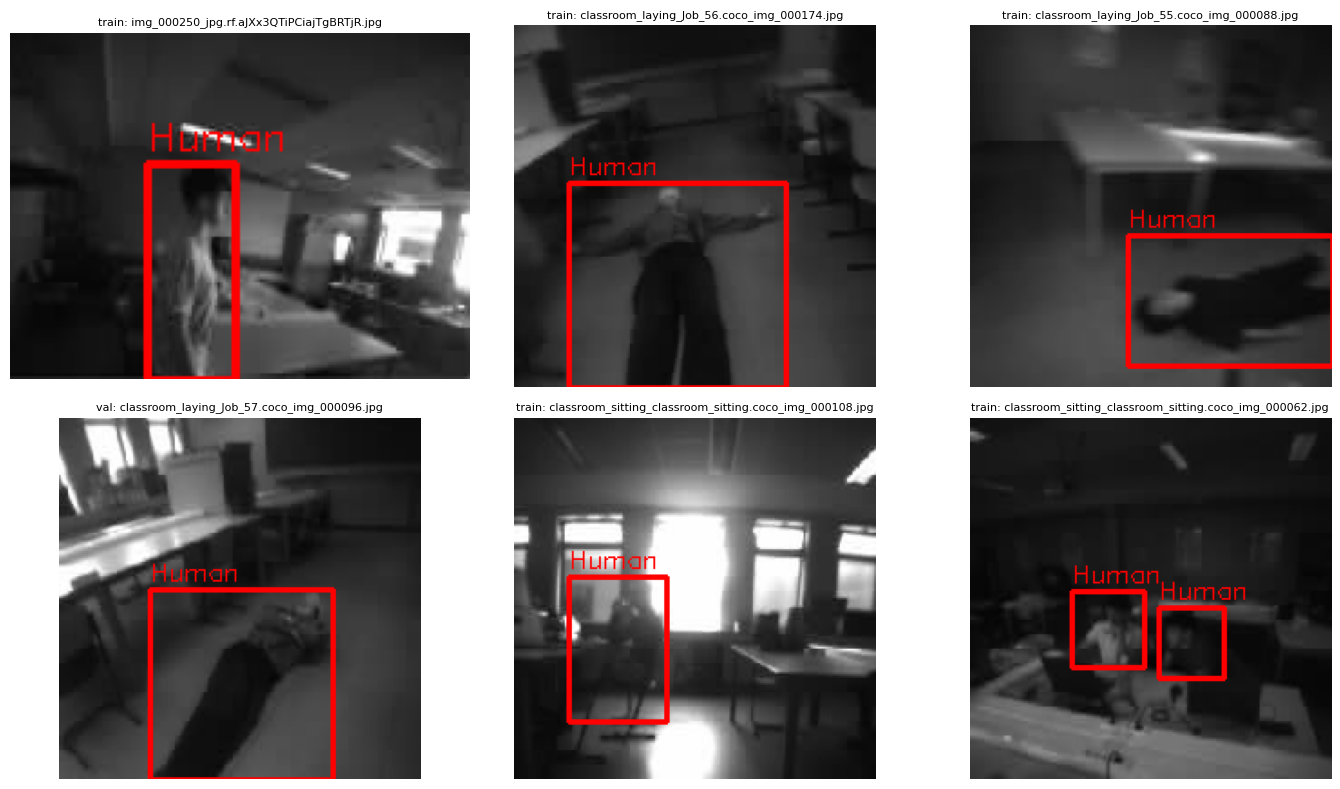

In [3]:
def draw_yolo_boxes(image_path: Path, label_path: Path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    for _, xc, yc, bw, bh in read_yolo_label(label_path):
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(image, "Human", (x1, max(y1 - 5, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1)
    return image

pairs = []
for split in SPLITS:
    for image_path in sorted((DATASET / "images" / split).iterdir()):
        if image_path.suffix.lower() in IMAGE_EXTS:
            pairs.append((split, image_path, DATASET / "labels" / split / f"{image_path.stem}.txt"))

sample = random.Random(SEED).sample(pairs, k=min(6, len(pairs)))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (split, image_path, label_path) in zip(axes.ravel(), sample):
    ax.imshow(draw_yolo_boxes(image_path, label_path))
    ax.set_title(f"{split}: {image_path.name}", fontsize=8)
    ax.axis("off")
plt.tight_layout()


## Training Configuration

Run this cell and check the printed settings before starting training.


In [4]:
IMG_SIZE = 224

TRAIN_ARGS = {
    "data": str(DATA_YAML),
    "epochs": 180,
    "imgsz": IMG_SIZE,
    "batch": 8,
    "patience": 45,
    "workers": 0,
    "device": "cpu",
    "cache": False,
    "optimizer": "auto",
    "lr0": 0.005,
    "lrf": 0.01,
    "warmup_epochs": 3.0,
    "cos_lr": True,
    "close_mosaic": 20,
    "mosaic": 0.55,
    "scale": 0.35,
    "translate": 0.08,
    "degrees": 2.0,
    "shear": 0.0,
    "perspective": 0.0,
    "flipud": 0.0,
    "fliplr": 0.5,
    "hsv_h": 0.0,
    "hsv_s": 0.0,
    "hsv_v": 0.30,
    "mixup": 0.0,
    "copy_paste": 0.0,
    "project": str(RUNS_DIR),
    "name": TRAIN_NAME,
    "exist_ok": True,
    "seed": SEED,
    "deterministic": True,
    "plots": True,
    "val": True,
    "save": True,
    "save_period": 20,
}

print("Model start weights:", PRETRAINED_WEIGHTS)
print("Model start note:", START_WEIGHTS_NOTE)
print("Training output:", RUNS_DIR / TRAIN_NAME)
print("Training args:")
for key, value in TRAIN_ARGS.items():
    print(f"  {key}: {value}")


Model start weights: C:\Users\Hecos\Documents\sem\industry\vslam\code\object_detection\notebooks\yolo26n.pt
Model start note: plain YOLO26n baseline checkpoint from local notebook folder
Training output: C:\Users\Hecos\Documents\sem\industry\vslam\code\object_detection\runs\yolo26\yolo26n_human_boxes_classroom_postures_from_baseline_cpu_img224
Training args:
  data: C:\Users\Hecos\Documents\sem\industry\vslam\code\object_detection\training_yolo26_boxes_with_classroom_postures\data.yaml
  epochs: 180
  imgsz: 224
  batch: 8
  patience: 45
  workers: 0
  device: cpu
  cache: False
  optimizer: auto
  lr0: 0.005
  lrf: 0.01
  warmup_epochs: 3.0
  cos_lr: True
  close_mosaic: 20
  mosaic: 0.55
  scale: 0.35
  translate: 0.08
  degrees: 2.0
  shear: 0.0
  perspective: 0.0
  flipud: 0.0
  fliplr: 0.5
  hsv_h: 0.0
  hsv_s: 0.0
  hsv_v: 0.3
  mixup: 0.0
  copy_paste: 0.0
  project: C:\Users\Hecos\Documents\sem\industry\vslam\code\object_detection\runs\yolo26
  name: yolo26n_human_boxes_classro

## Train

This is the long CPU cell. Expected runtime depends on the machine, but this config is intended to fit inside the 4-hour budget with early stopping.


In [ ]:
from ultralytics import YOLO

model = YOLO(str(PRETRAINED_WEIGHTS))
results = model.train(**TRAIN_ARGS)


New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.56  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core(TM) i7-13700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\Hecos\Documents\sem\industry\vslam\code\object_detection\training_yolo26_boxes_with_classroom_postures\data.yaml, degrees=2.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=180, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=3

## Validate Best Checkpoint On Test Split

Use test metrics for the final report. Validation metrics during training are for model selection.


In [ ]:
from ultralytics import YOLO

best_weights = RUNS_DIR / TRAIN_NAME / "weights" / "best.pt"
print("Best weights:", best_weights)

best_model = YOLO(str(best_weights))
test_metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=TRAIN_ARGS["imgsz"],
    device="cpu",
    workers=0,
    plots=True,
)
print(test_metrics)


## Compare Pretrained, Previous, And New Checkpoints

This keeps the comparison fair: same test split, same image size, same CPU device.


In [ ]:
from ultralytics import YOLO

models_to_compare = {
    "pretrained_yolo26n": "yolo26n.pt",
    "new_classroom_posture_detector": str(best_weights),
}

comparison_rows = []
for name, weights in models_to_compare.items():
    if weights is None:
        continue
    print(f"Validating {name}...")
    model = YOLO(weights)
    metrics = model.val(
        data=str(DATA_YAML),
        split="test",
        imgsz=TRAIN_ARGS["imgsz"],
        device="cpu",
        workers=0,
        plots=False,
        verbose=False,
    )
    comparison_rows.append(
        {
            "model": name,
            "precision": float(metrics.box.mp),
            "recall": float(metrics.box.mr),
            "mAP50": float(metrics.box.map50),
            "mAP50-95": float(metrics.box.map),
            "inference_ms": float(metrics.speed.get("inference", 0.0)),
        }
    )

for row in comparison_rows:
    print(row)


## Single-Image CPU Inference Timing

This approximates later deployment cost. It measures repeated prediction on one test frame after a warmup.


In [ ]:
def time_single_image(model, image_path: Path, imgsz: int, repeats: int = 30):
    model.predict(source=str(image_path), imgsz=imgsz, device="cpu", verbose=False)
    start = time.perf_counter()
    for _ in range(repeats):
        model.predict(source=str(image_path), imgsz=imgsz, device="cpu", verbose=False)
    elapsed = time.perf_counter() - start
    return elapsed * 1000 / repeats

test_images = [p for p in sorted((DATASET / "images" / "test").iterdir()) if p.suffix.lower() in IMAGE_EXTS]
image_path = test_images[0]
new_model = YOLO(str(best_weights))
ms = time_single_image(new_model, image_path, TRAIN_ARGS["imgsz"])
print("Image:", image_path)
print(f"Average CPU prediction time: {ms:.2f} ms/image at imgsz={TRAIN_ARGS['imgsz']}")


## Visual Prediction Check

Look for systematic misses on laying/sitting people, false positives on background, and badly oversized boxes.


In [ ]:
def draw_predictions(image_path: Path, model, title: str, imgsz: int, conf: float = 0.25):
    result = model.predict(
        source=str(image_path),
        imgsz=imgsz,
        conf=conf,
        device="cpu",
        verbose=False,
    )[0]
    plotted = result.plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    return plotted, title

previous_model = YOLO("yolo26n.pt")
new_model = YOLO(str(best_weights))

sample_images = random.Random(SEED + 2).sample(test_images, k=min(4, len(test_images)))
fig, axes = plt.subplots(len(sample_images), 2, figsize=(10, 4 * len(sample_images)))
if len(sample_images) == 1:
    axes = [axes]

for row_axes, image_path in zip(axes, sample_images):
    prev_plot, prev_title = draw_predictions(image_path, previous_model, "YOLO26n baseline", TRAIN_ARGS["imgsz"])
    new_plot, new_title = draw_predictions(image_path, new_model, "New detector", TRAIN_ARGS["imgsz"])

    row_axes[0].imshow(prev_plot)
    row_axes[0].set_title(f"{prev_title} | {image_path.name}", fontsize=8)
    row_axes[0].axis("off")

    row_axes[1].imshow(new_plot)
    row_axes[1].set_title(f"{new_title} | {image_path.name}", fontsize=8)
    row_axes[1].axis("off")

plt.tight_layout()
